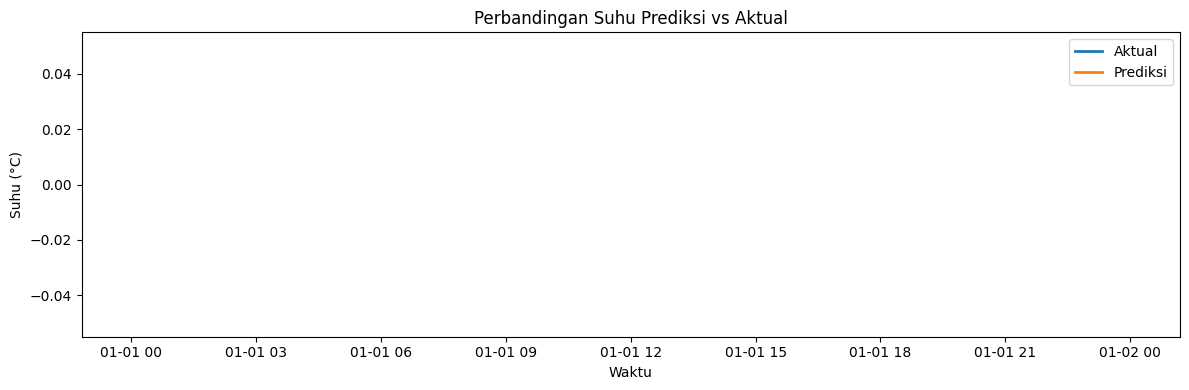

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pred = pd.read_csv("Main_model/prediction_forecast.csv")
pred["time"] = pd.to_datetime(pred["time"])

# ganti path ini sesuai file aktualmu
act = pd.read_csv("data/realtime_data.csv")  # atau "actual.csv"
act["time"] = pd.to_datetime(act["time"])

# samakan kolom suhu jika beda nama
# act["suhu"] = act["temperature"]  # contoh kalau kolomnya "temperature"

df = pd.merge(pred[["time","suhu"]], act[["time","suhu"]], on="time", suffixes=("_pred","_act"))

# pilih rentang beberapa hari
start = "2026-04-10 00:00:00"
end   = "2026-04-13 00:00:00"
cut = df[(df["time"] >= start) & (df["time"] <= end)].copy()

plt.figure(figsize=(12,4))
plt.plot(cut["time"], cut["suhu_act"], label="Aktual", linewidth=2)
plt.plot(cut["time"], cut["suhu_pred"], label="Prediksi", linewidth=2)
plt.title("Perbandingan Suhu Prediksi vs Aktual")
plt.xlabel("Waktu")
plt.ylabel("Suhu (°C)")
plt.legend()
plt.tight_layout()
plt.show()

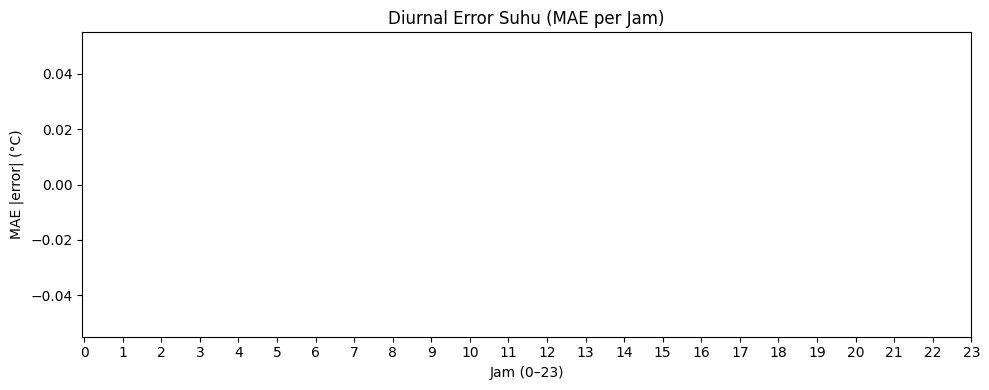

In [4]:
import numpy as np
import matplotlib.pyplot as plt

df["err"] = df["suhu_pred"] - df["suhu_act"]
df["abs_err"] = df["err"].abs()
df["hour"] = df["time"].dt.hour

diurnal = df.groupby("hour")["abs_err"].mean().reindex(range(24))

plt.figure(figsize=(10,4))
plt.bar(diurnal.index, diurnal.values)
plt.title("Diurnal Error Suhu (MAE per Jam)")
plt.xlabel("Jam (0–23)")
plt.ylabel("MAE |error| (°C)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

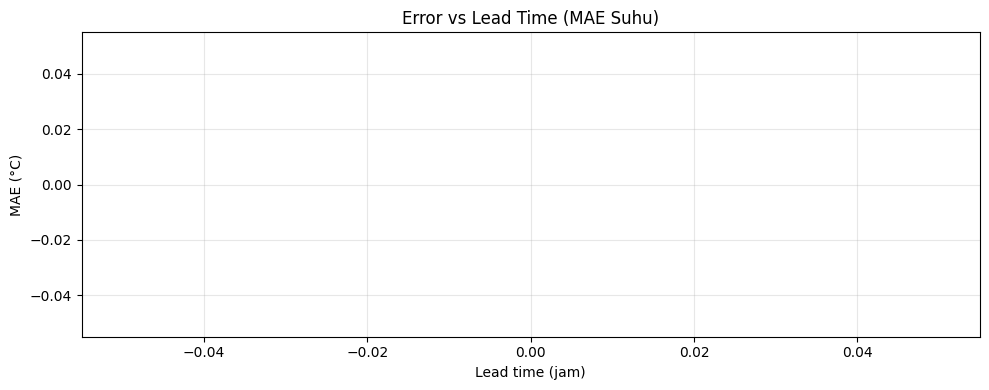

In [5]:
import numpy as np
import matplotlib.pyplot as plt

df = df.sort_values("time").copy()
t0 = df["time"].min()
df["lead_h"] = ((df["time"] - t0).dt.total_seconds() / 3600).round().astype(int)

# pilih lead time yang ingin diplot
lead_points = [1, 6, 12, 24, 48, 72, 168, 336, 720]  # jam
lead_mae = []

for L in lead_points:
    sub = df[df["lead_h"] == L]
    lead_mae.append(sub["abs_err"].mean() if len(sub) else np.nan)

plt.figure(figsize=(10,4))
plt.plot(lead_points, lead_mae, marker="o")
plt.title("Error vs Lead Time (MAE Suhu)")
plt.xlabel("Lead time (jam)")
plt.ylabel("MAE (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()